# Week 10.1 Lab - Learning a classical collision map and auditing it where DSMC looks

<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week10_1/W10_1_Collision_Map_Surrogate_Audit.ipynb)

**Research source (reading only):** E. Roohi, A. Shoja-Sani and S. Stefanov, *Physics constrained neural collision operators for hard sphere surrogates and ab initio angle prediction in DSMC*, Physics of Fluids 38, 057123 (2026), [10.1063/5.0328463](https://doi.org/10.1063/5.0328463).

**Scope:** an original CPU teaching analog. The potential is the reduced Lennard-Jones 12-6 model, **not** the ab initio Ar-Ar (Jaeger) potential of the article; the surrogate is a small scikit-learn MLP, **not** the article's network or checkpoint; no DSMC run is performed. What transfers is the *method of judgement*: a scattering surrogate must be audited under the collision states a solver actually visits and through the transport integrals that control viscosity and heat conduction, not by a global mean error.

Learning outcomes: (1) compute the classical deflection angle $\chi(b,E)$ by quadrature and verify it against two analytic limits; (2) build the viscosity and diffusion cross-sections and the collision integral $\Omega^{(2,2)}(T^*)$ and check them against the standard Lennard-Jones table; (3) fit a learned map $(E,b)\mapsto\cos\chi$ with an energy-wise split; (4) show that a small mean error can coexist with $O(1)$ local failures and quantify what those failures do to $\Omega^{(2,2)}$.

Runtime: about one minute on CPU. Restart and Run All. Nothing is written into retained results.

<!-- MIE690A article-aligned validation v4 -->

Teaching scope: Lennard-Jones analog, not a reproduction of the article model.

The pair audit samples random Maxwellian pairs (Gamma(3/2) energies), conditional on the retained energy range. It does not include relative-speed weighting and is not a sample of accepted DSMC collision events. Numerical tables below are finite-grid quadrature references, not exact transport integrals.

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week10_1"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import sys
# Local checkout: add the repository root so that `flowmllab` imports without installation.
_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "flowmllab").is_dir()), None)
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
import numpy as np, matplotlib.pyplot as plt
from flowmllab.scattering_lab import (deflection_angle, rutherford_angle, hard_sphere_angle, coulomb_repulsive,
    build_table, transport_cross_sections, omega22_star, fit_surrogate, predict_surrogate,
    collision_weighted_audit, sample_collision_states, B_MAX_DEFAULT)
print("Teaching analog: reduced Lennard-Jones potential; no article checkpoint or DSMC run.")

Teaching analog: reduced Lennard-Jones potential; no article checkpoint or DSMC run.


## 1. The deflection angle and its two analytic controls

For a central potential $V(r)$, relative energy $E=\tfrac12\mu g^2$ and impact parameter $b$, the classical deflection is

$$\chi(b,E)=\pi-2b\int_{r_{\min}}^{\infty}\frac{dr}{r^{2}\sqrt{1-b^{2}/r^{2}-V(r)/E}},\qquad 1-\frac{b^2}{r_{\min}^2}-\frac{V(r_{\min})}{E}=0 .$$

The integrand has an inverse-square-root singularity at the turning point $r_{\min}$; the code removes it with the substitution $r=r_{\min}/(1-u^2)$. Two cases have closed forms and are used as controls before any fitting: the repulsive Coulomb potential $V=k/r$ (Rutherford, $\tan(\chi/2)=k/2Eb$) and the rigid sphere ($\chi=2\arccos(b/d)$), approached here by a very steep power law.

In [2]:
k = 0.8
worst = max(abs(deflection_angle(b, e, coulomb_repulsive(k)) - rutherford_angle(b, e, k))
            for e in (0.7, 2.0, 9.0) for b in (0.2, 1.0, 3.5))
steep = lambda r: (1.0 / np.asarray(r, float)) ** 200
hs = max(abs(deflection_angle(b, 5.0, steep) - float(hard_sphere_angle(b))) for b in (0.2, 0.6, 0.95))
print(f"Rutherford control: max |chi_num - chi_analytic| = {worst:.2e} rad")
print(f"Rigid-sphere control (steep power law): max deviation = {hs:.3f} rad")

Rutherford control: max |chi_num - chi_analytic| = 3.60e-13 rad
Rigid-sphere control (steep power law): max deviation = 0.019 rad


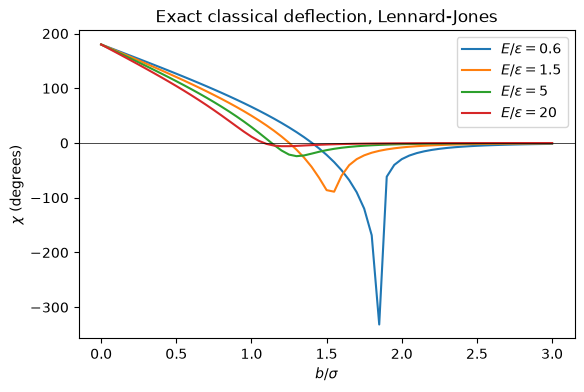

In [3]:
impact = np.linspace(0.0, B_MAX_DEFAULT, 61)
fig, ax = plt.subplots(figsize=(6.4, 4))
for e in (0.6, 1.5, 5.0, 20.0):
    ax.plot(impact, np.degrees([deflection_angle(float(b), e) for b in impact]), label=fr"$E/\epsilon={e:g}$")
ax.axhline(0, color="k", lw=0.5); ax.set_xlabel(r"$b/\sigma$"); ax.set_ylabel(r"$\chi$ (degrees)")
ax.set_title("Exact classical deflection, Lennard-Jones"); ax.legend(); plt.show()

Read the curves: head-on collisions ($b\to0$) give $\chi=\pi$; the attractive well makes $\chi$ negative at intermediate $b$ (net attraction) with a minimum, the **rainbow** angle; at the zero crossing (the **glory**) the deflection vanishes although the trajectory is strongly disturbed. These features are where a smooth regressor is most likely to fail, and they sharpen as $E/\epsilon$ decreases.

## 2. From angles to transport: cross-sections and $\Omega^{(2,2)}$

$$Q^{(1)}(E)=2\pi\!\int_0^{b_{\max}}(1-\cos\chi)\,b\,db,\qquad Q^{(2)}(E)=2\pi\!\int_0^{b_{\max}}(1-\cos^2\chi)\,b\,db,\qquad \Omega^{(2,2)}(T^*)=\tfrac12\int_0^\infty e^{-x}x^{3}Q^{(2)}(xT^*)\,dx,\quad x=\frac{E}{kT}.$$

$Q^{(2)}$ controls viscosity and thermal conductivity. Normalizing $\Omega^{(2,2)}$ by its rigid-sphere value $2\pi\sigma^2$ gives the reduced collision integral tabulated for the Lennard-Jones potential (Hirschfelder, Curtiss and Bird). Agreement with that table is an end-to-end check of the quadrature, the cross-sections and the thermal averaging, independent of any learning.

In [4]:
energies = np.geomspace(0.6, 120.0, 40)          # covers x = E/kT up to 20 at T* = 6
table = build_table(energies, impact)              # 40 x 61 exact deflections (a few seconds)
q1, q2 = transport_cross_sections(impact, table.cos_chi)
reference = {1.0: 1.587, 1.5: 1.314, 2.0: 1.175, 3.0: 1.039, 4.0: 0.9700, 6.0: 0.8963, 10.0: 0.8242}
print("T*     Omega22* computed   HCB table   rel. diff")
for t_star, ref in reference.items():
    val = omega22_star(energies, q2, t_star)
    print(f"{t_star:4.1f}   {val:8.4f}           {ref:6.4f}    {100*(val-ref)/ref:+.2f} %")

T*     Omega22* computed   HCB table   rel. diff
 1.0     1.5862           1.5870    -0.05 %
 1.5     1.3165           1.3140    +0.19 %
 2.0     1.1785           1.1750    +0.29 %
 3.0     1.0418           1.0390    +0.27 %
 4.0     0.9729           0.9700    +0.29 %
 6.0     0.8990           0.8963    +0.30 %
10.0     0.8251           0.8242    +0.11 %


## 3. A learned collision map with an honest split

The surrogate maps $(\log E,\,b)$ to $\cos\chi$. Training uses the 40 tabulated energies; **evaluation uses the 39 geometric midpoint energies, which never appear in training**, so the test measures interpolation between energy levels, the situation a DSMC solver creates continuously. A second, harder audit samples the collision states a solver would actually visit at temperature $T^*$: relative energies follow the Maxwellian pair distribution ($E/kT\sim\Gamma(3/2)$) and impact parameters are equal-area on the collision disk ($b=b_{\max}\sqrt U$).

C:\Users\roohie\OneDrive - University of Massachusetts\Documents\ChatGPT\FlowMLLAB\.tmp\week14-venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


unseen energies: RMS error in cos chi = 0.0350, max |error| = 1.093


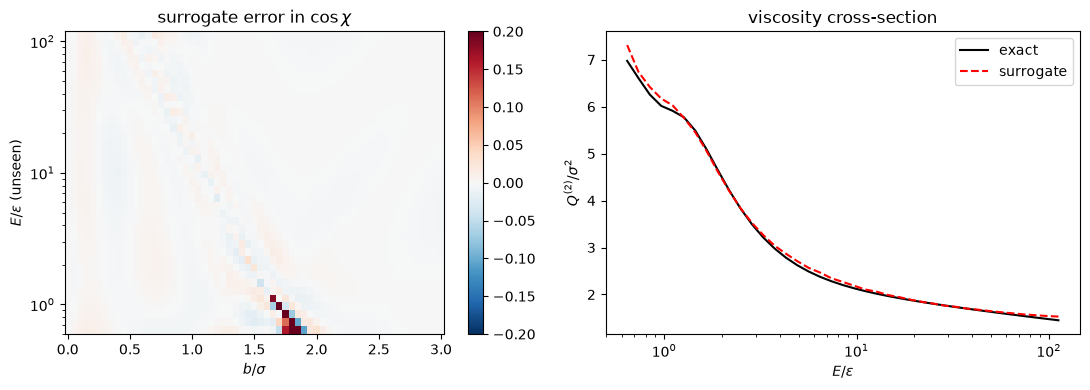

Returned cos(chi) range: -1.0 1.0


In [5]:
fitted = fit_surrogate(table, hidden=(48, 48), seed=0)
test_energies = np.sqrt(energies[:-1] * energies[1:])
test_table = build_table(test_energies, impact)
pred = predict_surrogate(fitted, test_energies, impact)
err = pred - test_table.cos_chi
q2_exact = transport_cross_sections(impact, test_table.cos_chi)[1]
q2_surr = transport_cross_sections(impact, pred)[1]
print(f"unseen energies: RMS error in cos chi = {np.sqrt(np.mean(err**2)):.4f}, max |error| = {np.abs(err).max():.3f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].pcolormesh(impact, test_energies, err, cmap="RdBu_r", vmin=-0.2, vmax=0.2, shading="auto")
ax[0].set_yscale("log"); ax[0].set_xlabel(r"$b/\sigma$"); ax[0].set_ylabel(r"$E/\epsilon$ (unseen)"); ax[0].set_title(r"surrogate error in $\cos\chi$")
fig.colorbar(im, ax=ax[0])
ax[1].plot(test_energies, q2_exact, "k-", label="exact"); ax[1].plot(test_energies, q2_surr, "r--", label="surrogate")
ax[1].set_xscale("log"); ax[1].set_xlabel(r"$E/\epsilon$"); ax[1].set_ylabel(r"$Q^{(2)}/\sigma^2$"); ax[1].legend(); ax[1].set_title("viscosity cross-section")
plt.tight_layout(); plt.show()
print('Returned cos(chi) range:', float(pred.min()), float(pred.max()))
assert np.all(np.isfinite(pred))

In [6]:
for t_star in (1.5, 3.0, 6.0):
    audit = collision_weighted_audit(fitted, t_star, count=3000, seed=1)
    om_exact = omega22_star(test_energies, q2_exact, t_star); om_surr = omega22_star(test_energies, q2_surr, t_star)
    print(f"T*={t_star:3.1f}: Maxwellian-pair-weighted RMS(cos) = {audit['rms_cos_error']:.4f}, max = {audit['max_abs_cos_error']:.3f}, "
          f"fraction |err|>0.1 = {audit['fraction_abs_error_above_0p1']:.3f}, Omega22* rel. error = {100*abs(om_surr-om_exact)/om_exact:.2f} %")

T*=1.5: Maxwellian-pair-weighted RMS(cos) = 0.0507, max = 1.767, fraction |err|>0.1 = 0.004, Omega22* rel. error = 2.17 %


T*=3.0: Maxwellian-pair-weighted RMS(cos) = 0.0633, max = 1.725, fraction |err|>0.1 = 0.004, Omega22* rel. error = 1.99 %


T*=6.0: Maxwellian-pair-weighted RMS(cos) = 0.0274, max = 1.461, fraction |err|>0.1 = 0.001, Omega22* rel. error = 0.91 %


## 4. Discussion

1. The table shows a small RMS error but an $O(1)$ maximum error. Locate it in the error map. Which physical feature of $\chi(b,E)$ is being missed, and why does a smooth regressor struggle there?
2. $\Omega^{(2,2)}$ is far less sensitive than the pointwise error. Explain, using the weights $(1-\cos^2\chi)\,b$ and $x^3e^{-x}$, which collision states dominate viscosity and why the localized failure barely registers. Which transport property would be more sensitive?
3. The article stresses that a global mean cannot replace a *collision-distribution-weighted* assessment. Re-run the audit at $T^*=0.8$ (edit the loop). What changes, and what does the discarded-state count in `collision_weighted_audit` tell you about the range the surrogate was trained on?
4. Propose a loss weighting that follows the visit distribution of a DSMC solver at a given temperature instead of uniform $(E,b)$ samples. What is the risk for a flow with a shock, where the local temperature spans a decade?
5. In a DSMC code both the exact and the learned angle are stored as a lookup table. Why does this make a wall-clock speed comparison in the solver meaningless as a test of the *model*, and what should be compared instead?

## 5. Exit assessment and reproducibility

Submit: the two control errors, the $\Omega^{(2,2)*}$ comparison table, the error map with the failure located and named, the Maxwellian-pair-weighted audit at three temperatures, and one paragraph on why the pointwise and transport-level verdicts differ.

The retained evidence is regenerated without touching existing results by
`python qa/run_scattering_lab.py --output tmp/scattering-new`; unit tests in `tests/test_scattering_lab.py` include the Rutherford, rigid-sphere and Hirschfelder-table checks.

A maximum absolute error of 1.78 alone does NOT prove an out-of-bounds prediction: two numbers in [-1,1] can differ by 2. Inspect the prediction range and the clipping policy separately. A tanh output guarantees boundedness but cannot guarantee accurate scattering near sharp features.

Implementation detail: `predict_surrogate` applies `np.clip(raw_prediction, -1, 1)` before returning values. The reported physical integrals therefore use clipped predictions; the raw MLP itself has an unbounded linear head. The printed range audits returned values, not the raw head. An optimizer iteration-limit warning means optimization stopped at its budget, not that convergence was demonstrated.